In [1]:
import tensorflow
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense,BatchNormalization,Dropout, LeakyReLU,Conv2D,MaxPooling2D,GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [3]:
# Flatten the label arrays
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# Define selected class labels (airplane=0, automobile=1, bird=2, cat=3)
selected_classes = [0, 1, 2, 3,4,5,6,7]

# Create boolean masks to select only the desired classes
train_mask = np.isin(y_train, selected_classes)
test_mask = np.isin(y_test, selected_classes)

# Apply the masks to filter images and labels
X_train_filtered = X_train[train_mask]
y_train_filtered = y_train[train_mask]
X_test_filtered = X_test[test_mask]
y_test_filtered = y_test[test_mask]

# Normalize the image pixel values to [0, 1]
X_train_filtered = X_train_filtered / 255.0
X_test_filtered = X_test_filtered / 255.0

# One-hot encode the labels with num_classes=4 (since we have 8 classes)
y_train_oh = to_categorical(y_train_filtered, num_classes=8)
y_test_oh = to_categorical(y_test_filtered, num_classes=8)

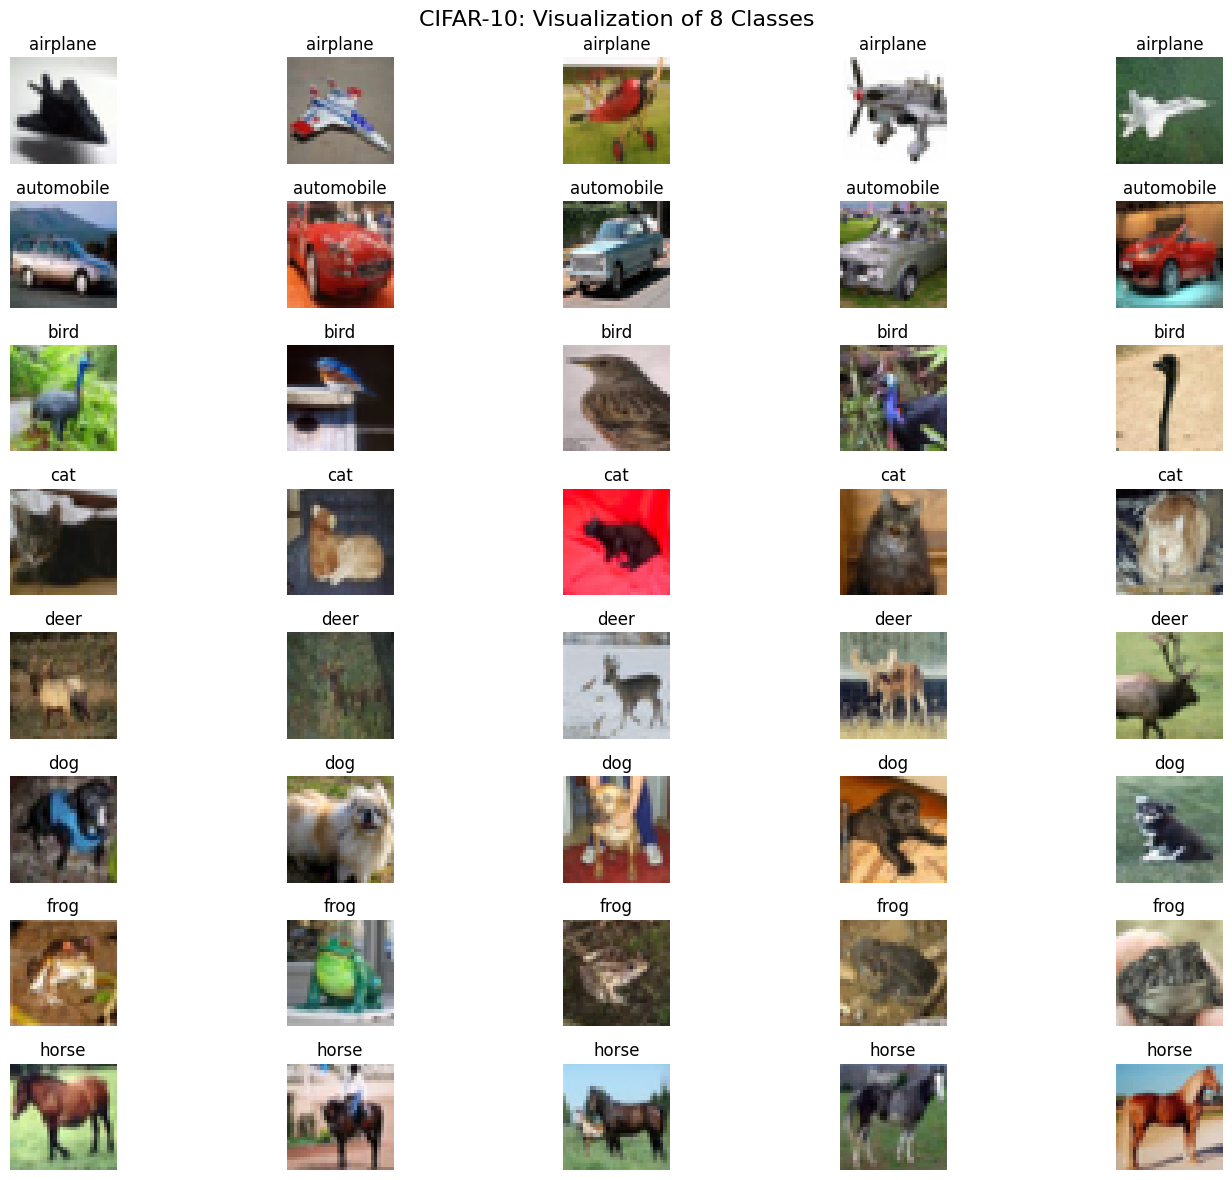

In [4]:
# Class names for 8 selected CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse']
selected_classes = [0, 1, 2, 3, 4, 5, 6, 7]  # Corresponding class indices

plt.figure(figsize=(15, 12))

# Plot 5 images for each of the 8 selected classes
for class_index, class_label in enumerate(selected_classes):
    # Get indices of training images for this class
    indices = np.where(y_train_filtered == class_label)[0]
    # Plot 5 sample images for the class
    for i in range(5):
        plt.subplot(8, 5, class_index * 5 + i + 1)
        plt.imshow(X_train_filtered[indices[i]])
        plt.title(class_names[class_index])
        plt.axis('off')

plt.suptitle("CIFAR-10: Visualization of 8 Classes", fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
model = Sequential()
model.add(Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
#model.add(Dropout(0.4))

model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='softmax'))

In [16]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 32, 32, 64)        1792      
                                                                 
 batch_normalization_5 (Batc  (None, 32, 32, 64)       256       
 hNormalization)                                                 
                                                                 
 conv2d_6 (Conv2D)           (None, 32, 32, 64)        36928     
                                                                 
 batch_normalization_6 (Batc  (None, 32, 32, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 16, 16, 64)       0         
 2D)                                                             
                                                      

In [23]:
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy',metrics = ['accuracy'])

In [24]:
history =model.fit(X_train_filtered, y_train_oh, epochs=19,validation_data=(X_test_filtered,y_test_oh), batch_size=64)

Epoch 1/19
625/625 [==============================] - 9s 14ms/step - loss: 1.3779 - accuracy: 0.4976 - val_loss: 1.5708 - val_accuracy: 0.4376
Epoch 2/19
625/625 [==============================] - 8s 12ms/step - loss: 1.0141 - accuracy: 0.6352 - val_loss: 0.9610 - val_accuracy: 0.6534
Epoch 3/19
625/625 [==============================] - 8s 13ms/step - loss: 0.8118 - accuracy: 0.7131 - val_loss: 0.8144 - val_accuracy: 0.7104
Epoch 4/19
625/625 [==============================] - 9s 15ms/step - loss: 0.6853 - accuracy: 0.7644 - val_loss: 0.6692 - val_accuracy: 0.7651
Epoch 5/19
625/625 [==============================] - 9s 15ms/step - loss: 0.5881 - accuracy: 0.7979 - val_loss: 0.6539 - val_accuracy: 0.7732
Epoch 6/19
625/625 [==============================] - 10s 16ms/step - loss: 0.5165 - accuracy: 0.8228 - val_loss: 0.6492 - val_accuracy: 0.7772
Epoch 7/19
625/625 [==============================] - 10s 16ms/step - loss: 0.4568 - accuracy: 0.8432 - val_loss: 0.6189 - val_accuracy: 0.79

In [25]:
model.evaluate(X_test_filtered, y_test_oh)


250/250 [==============================] - 1s 5ms/step - loss: 0.6465 - accuracy: 0.8235


[0.6465275287628174, 0.8234999775886536]

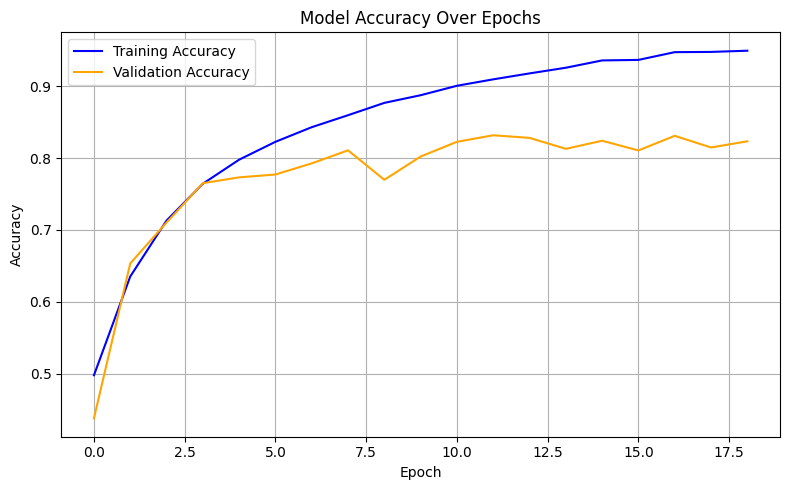

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step


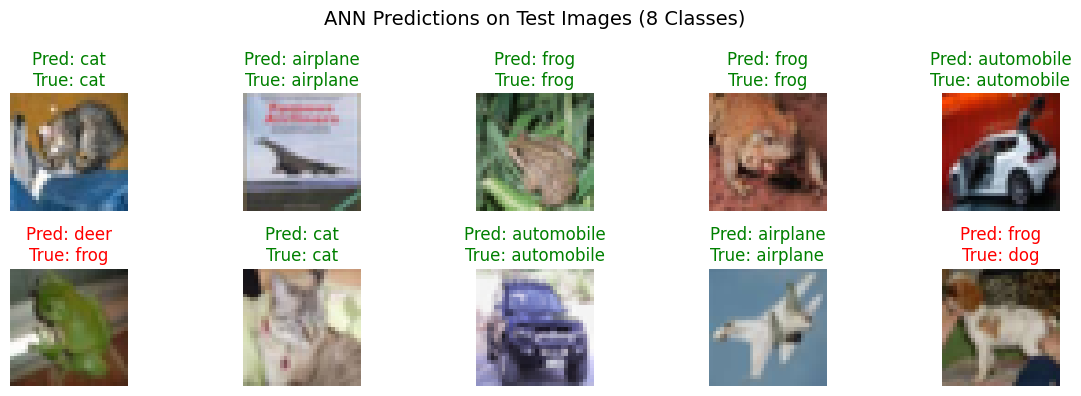

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Predict on first 10 test images
pred_probs = model.predict(X_test_filtered[:10])
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(y_test_oh[:10], axis=1)

# Class labels for 8 selected classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse']

# Plot predictions with color-coded titles
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_filtered[i])
    plt.title(f"Pred: {class_names[pred_classes[i]]}\nTrue: {class_names[true_classes[i]]}",
              color="green" if pred_classes[i] == true_classes[i] else "red")
    plt.axis('off')

plt.suptitle("ANN Predictions on Test Images (8 Classes)", fontsize=14)
plt.tight_layout()
plt.show()
